Libraries installed successfully..
Libraries installed successfully..

[PIPELINE] Starting Tabular Data Processing Pipeline...


[ROUTE] Successfully sent to Tabular EDA.


-> Processing data file: 'spambase_csv.xls'



The shape of the dataset: (4601, 58)
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00

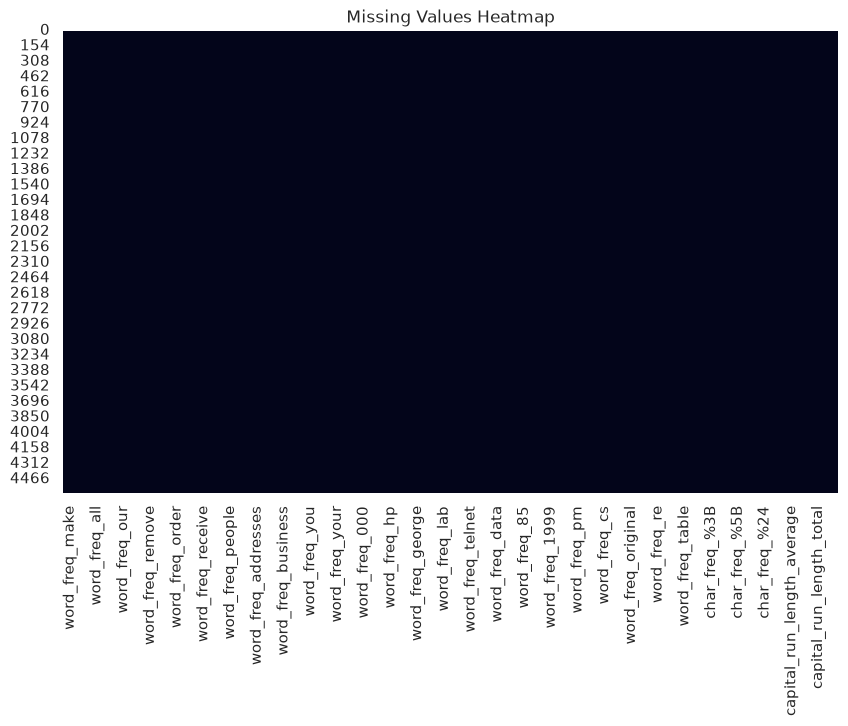



Central Tendency: 

Column: 'word_freq_make'
  -> Mean:   0.10
  -> Median: 0.00
  -> Mode:   0.0
  -> skew:   5.675639163765851
  -> Kurtosis:   49.30506415870118
count    4601.000000
mean        0.104553
std         0.305358
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.540000
Name: word_freq_make, dtype: float64

Column: 'word_freq_address'
  -> Mean:   0.21
  -> Median: 0.00
  -> Mode:   0.0
  -> skew:   10.086810872543571
  -> Kurtosis:   105.64747160937861
count    4601.000000
mean        0.213015
std         1.290575
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.280000
Name: word_freq_address, dtype: float64

Column: 'word_freq_all'
  -> Mean:   0.28
  -> Median: 0.00
  -> Mode:   0.0
  -> skew:   3.0092485272970904
  -> Kurtosis:   13.308743418467486
count    4601.000000
mean        0.280656
std         0.504143
min         0.000000
25%         0.000000
50%         0.000000

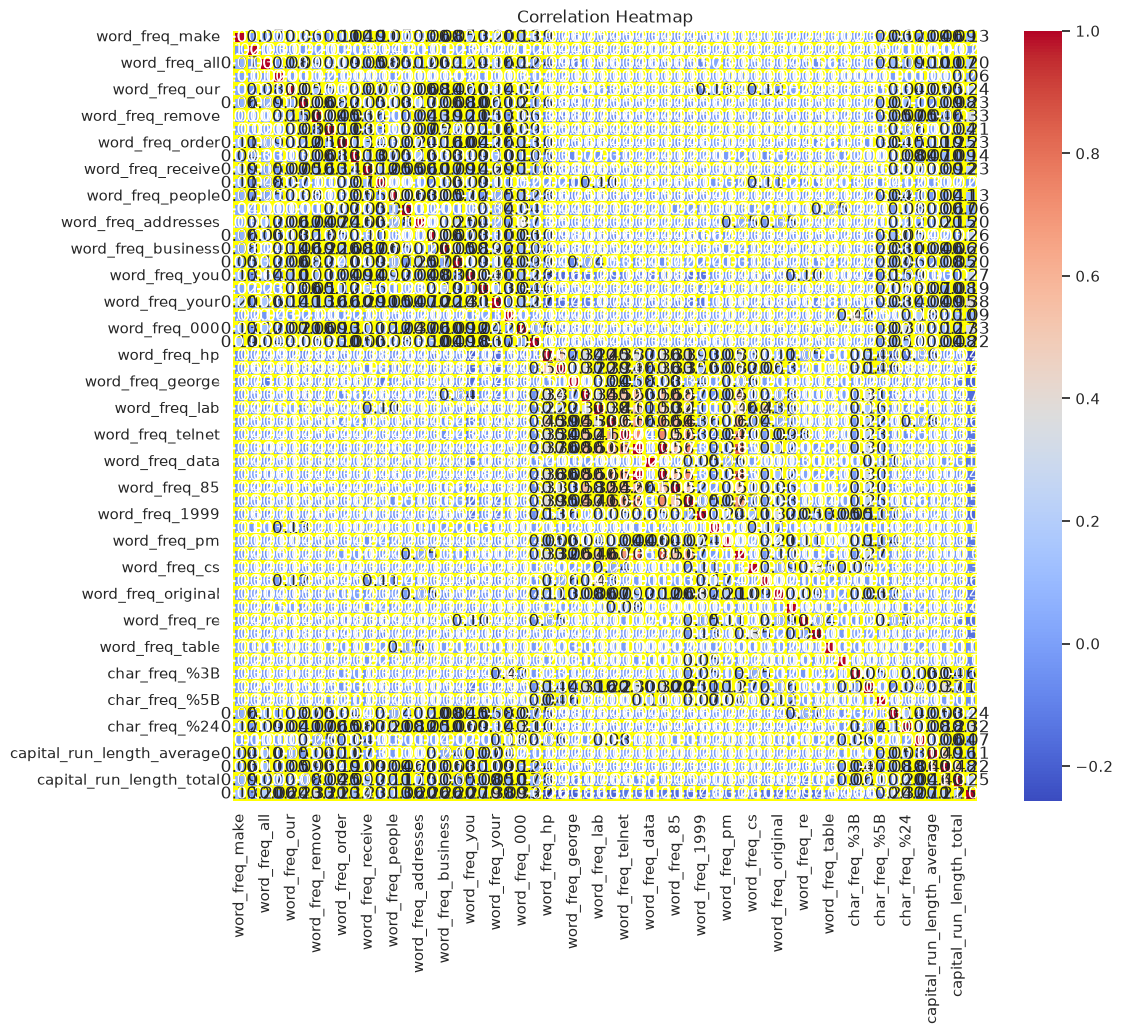



                      features         VIF
31               word_freq_857  135.318334
33               word_freq_415  131.995049
39            word_freq_direct    4.063252
57                       class    3.516051
35        word_freq_technology    2.831165
30            word_freq_telnet    2.714822
29              word_freq_labs    2.459242
55  capital_run_length_longest    2.351391
18               word_freq_you    2.155886
27               word_freq_650    2.121127
20              word_freq_your    1.998017
28               word_freq_lab    1.956195
34                word_freq_85    1.894627
49               char_freq_%28    1.813722
56    capital_run_length_total    1.788244
24                word_freq_hp    1.727186
25               word_freq_hpl    1.668961
41           word_freq_meeting    1.497985
22               word_freq_000    1.493752
54  capital_run_length_average    1.483592
11              word_freq_will    1.467569
14         word_freq_addresses    1.447615
2        

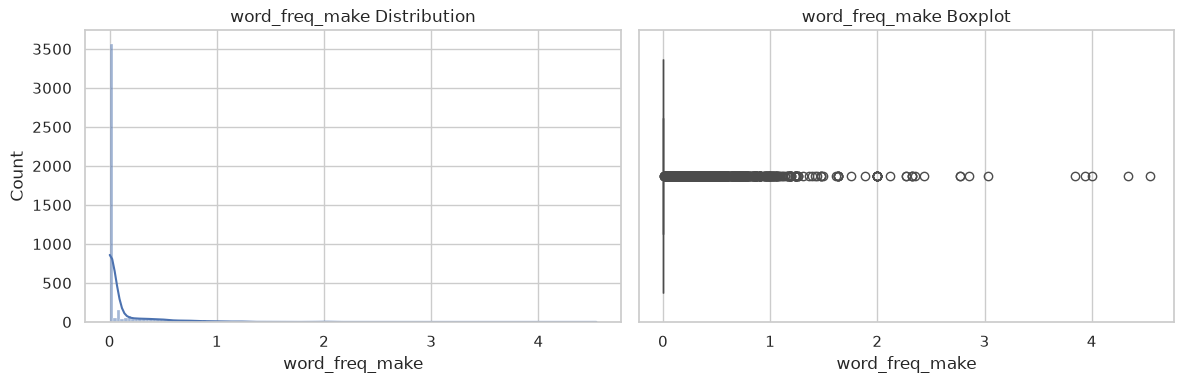

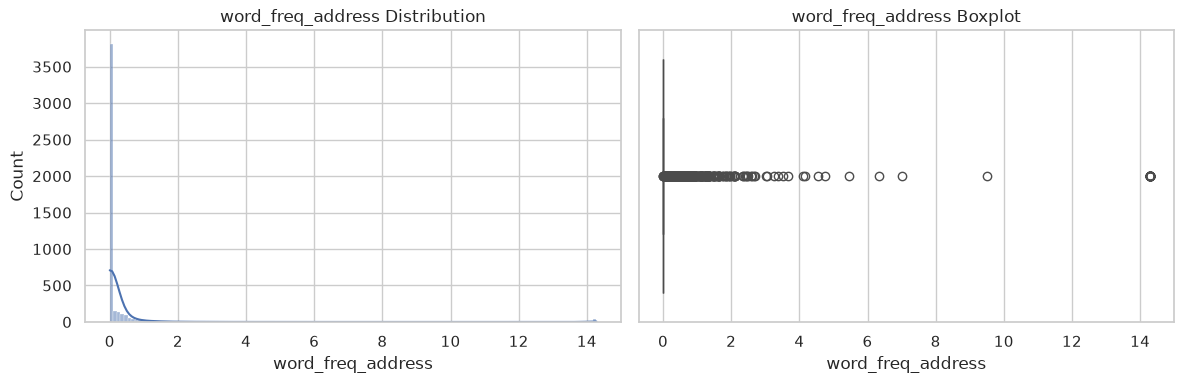

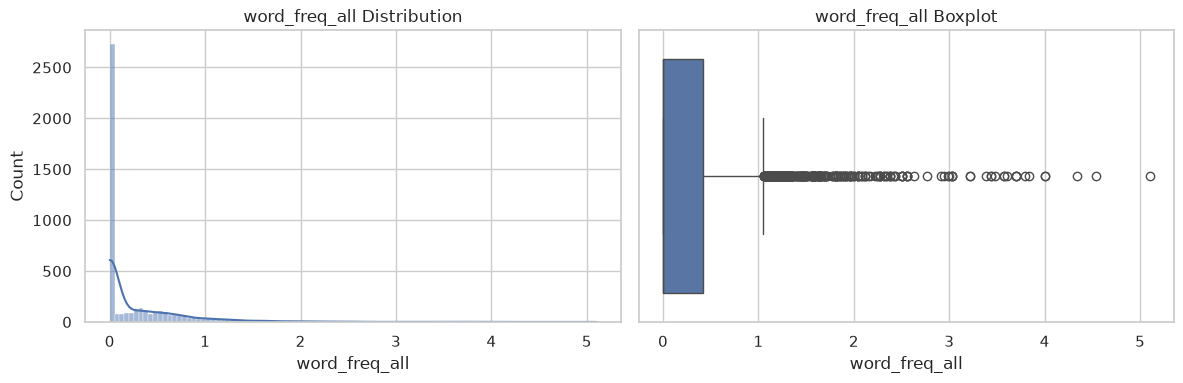

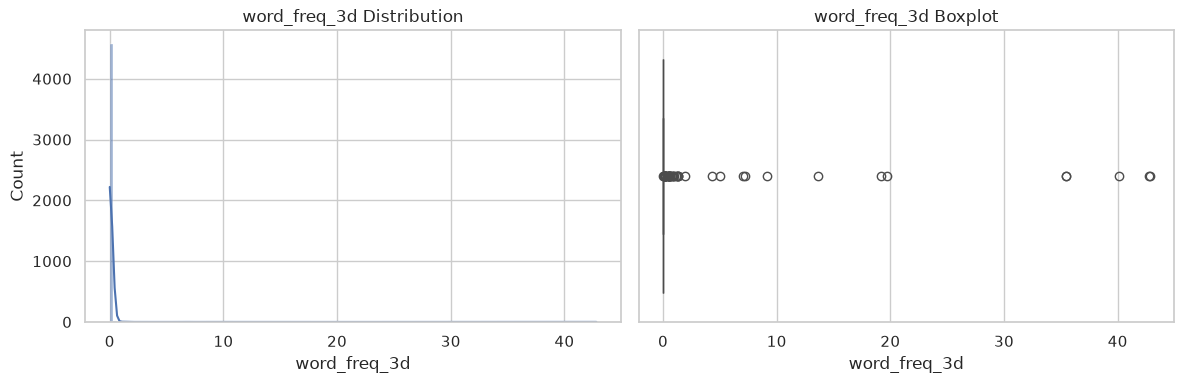

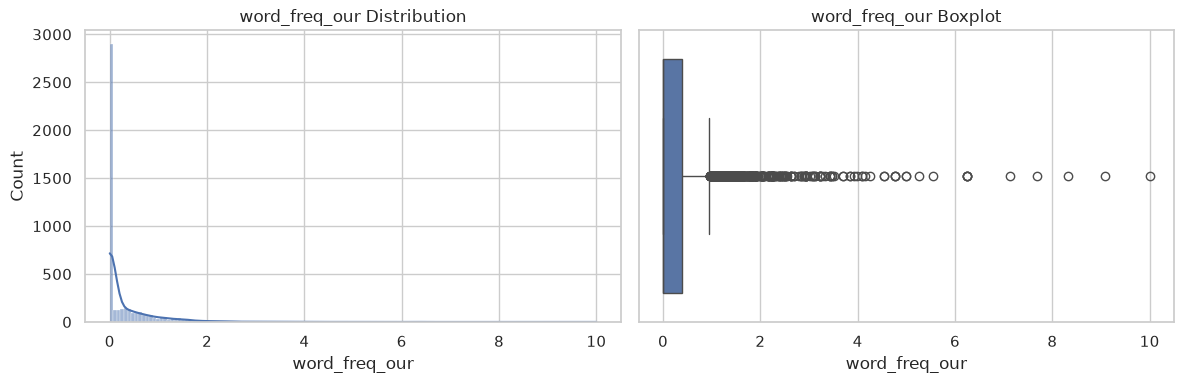

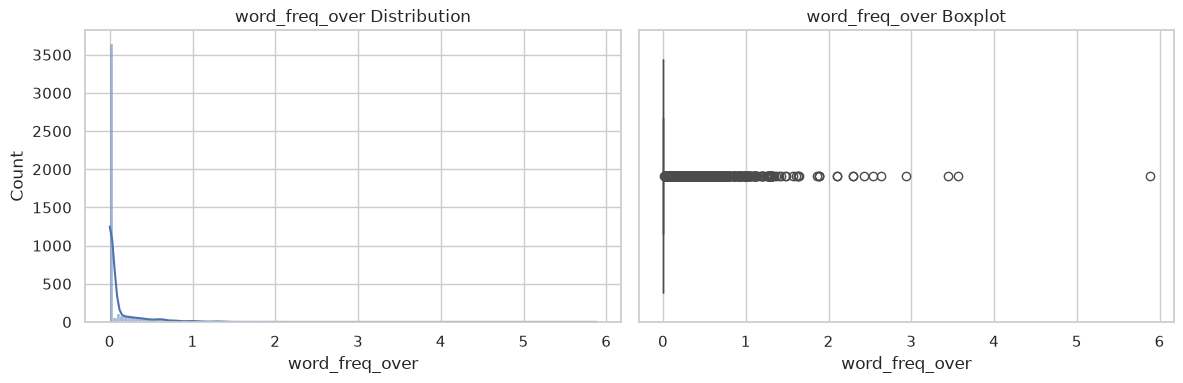

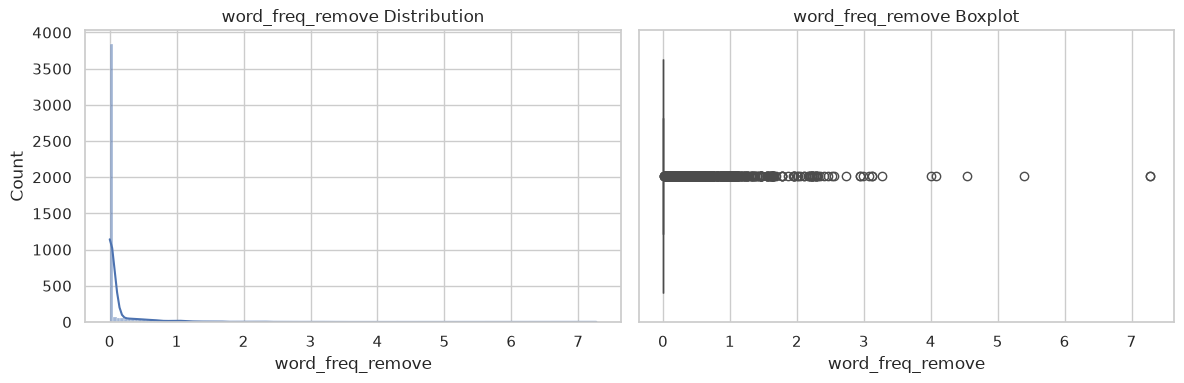

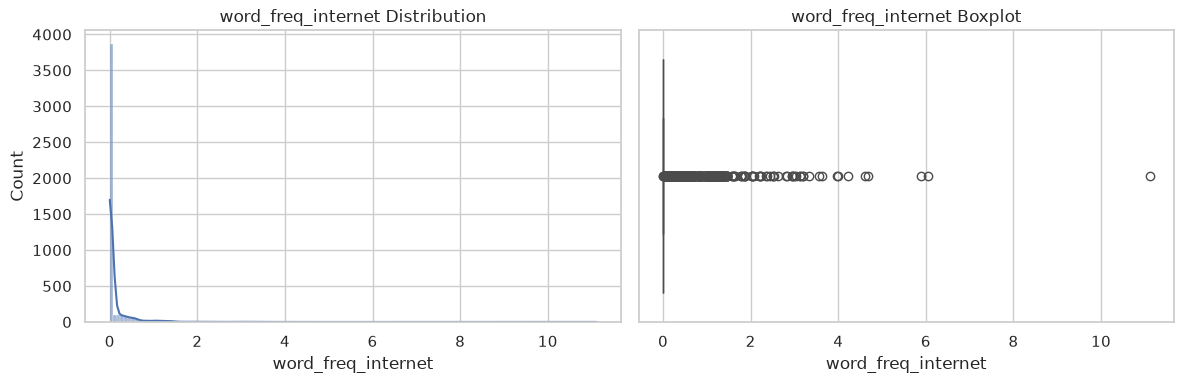

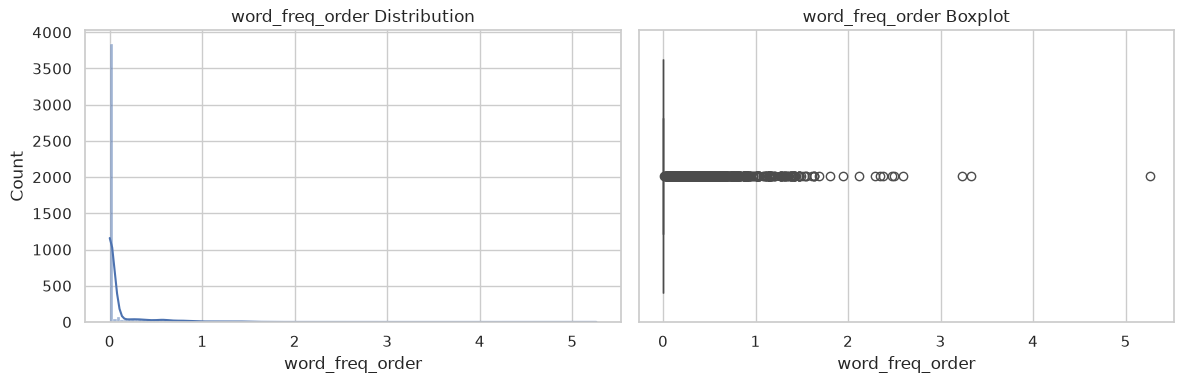

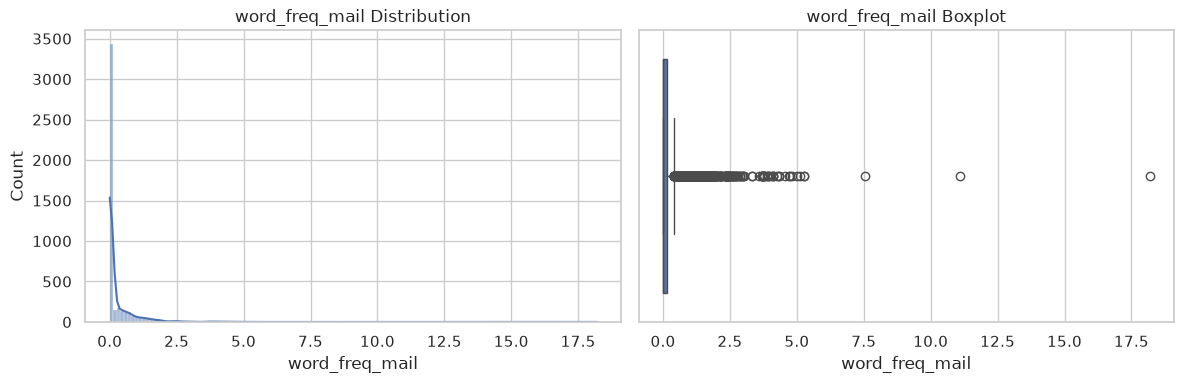

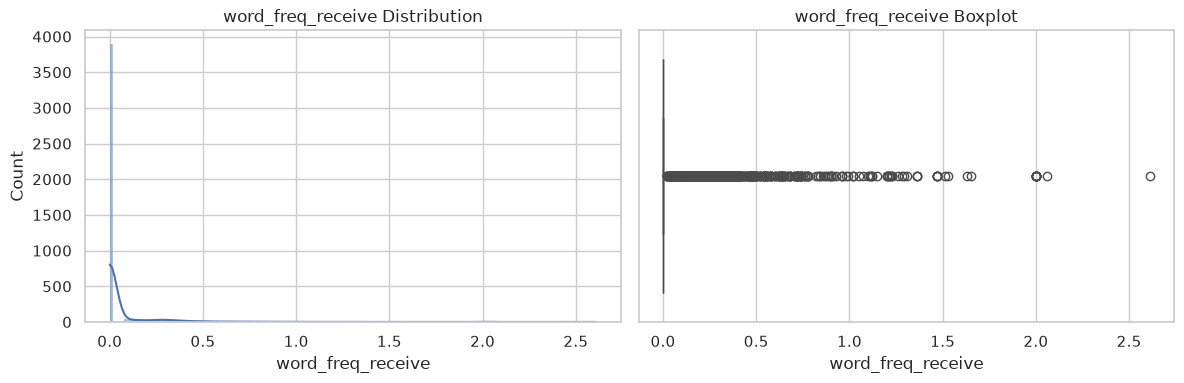

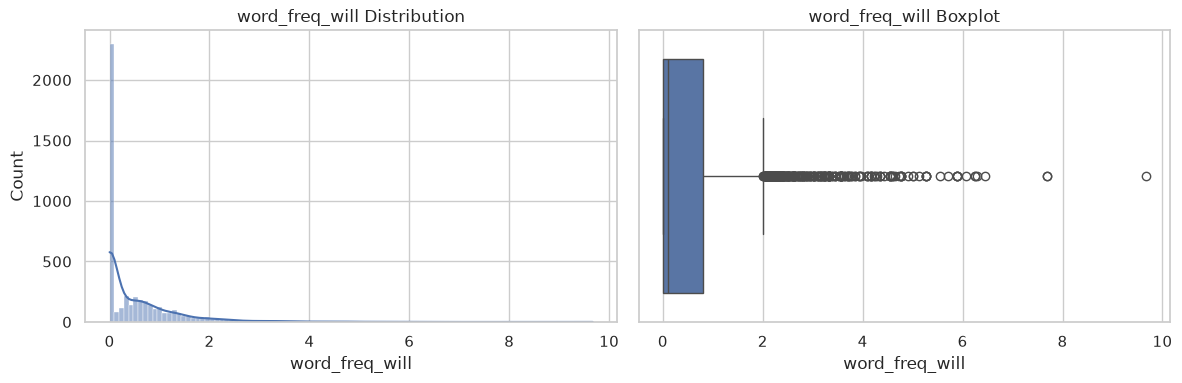

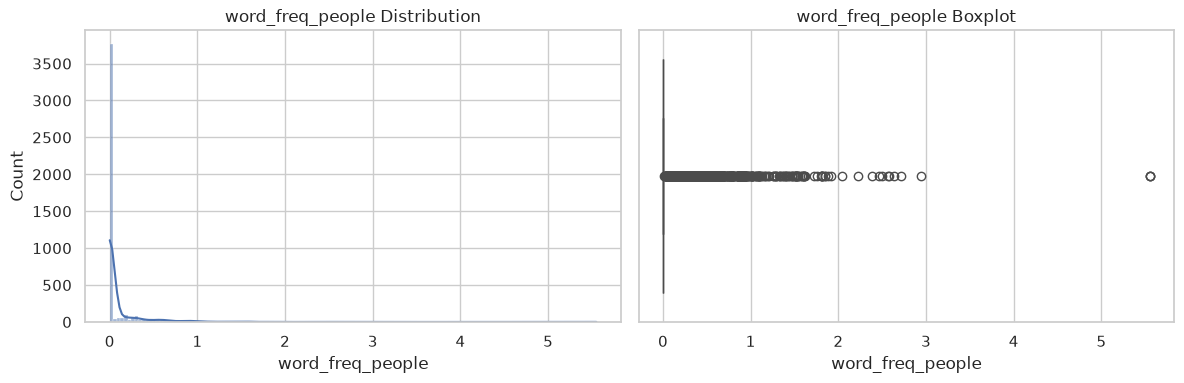

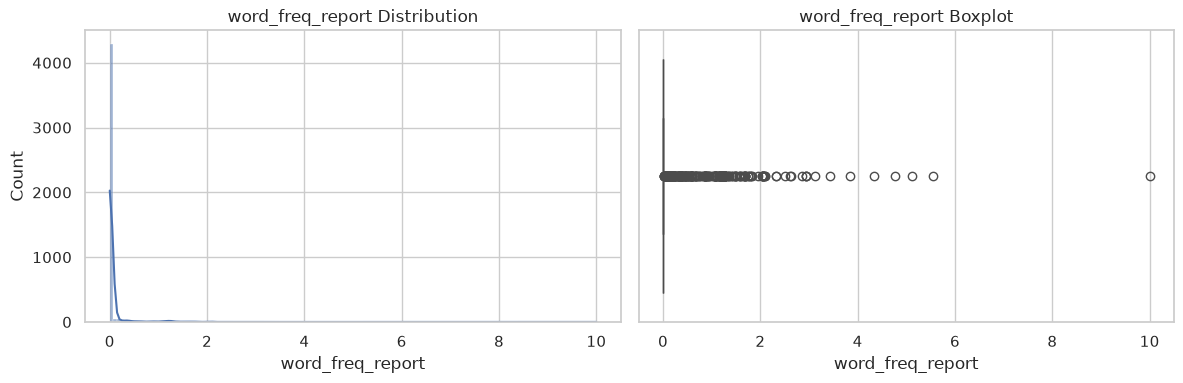

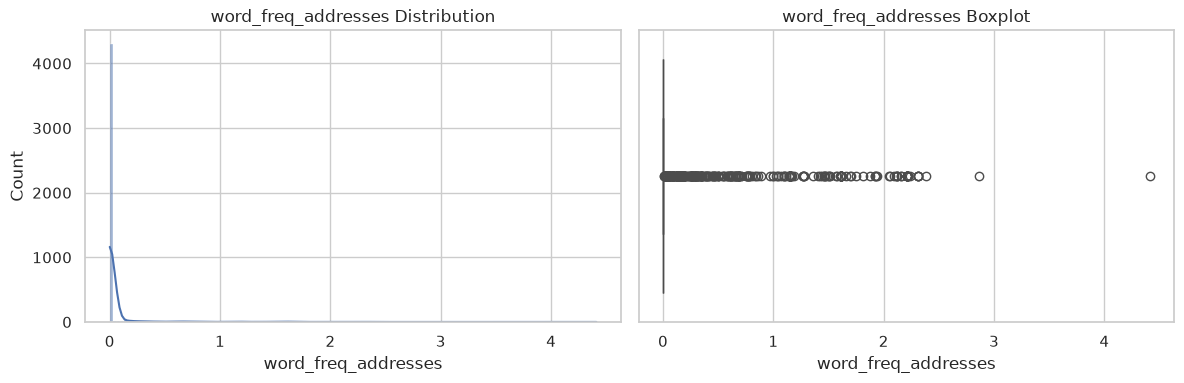

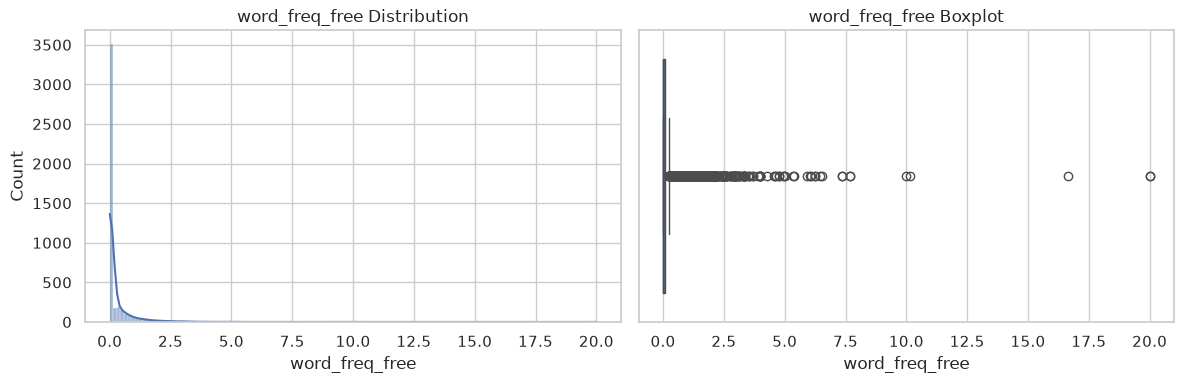

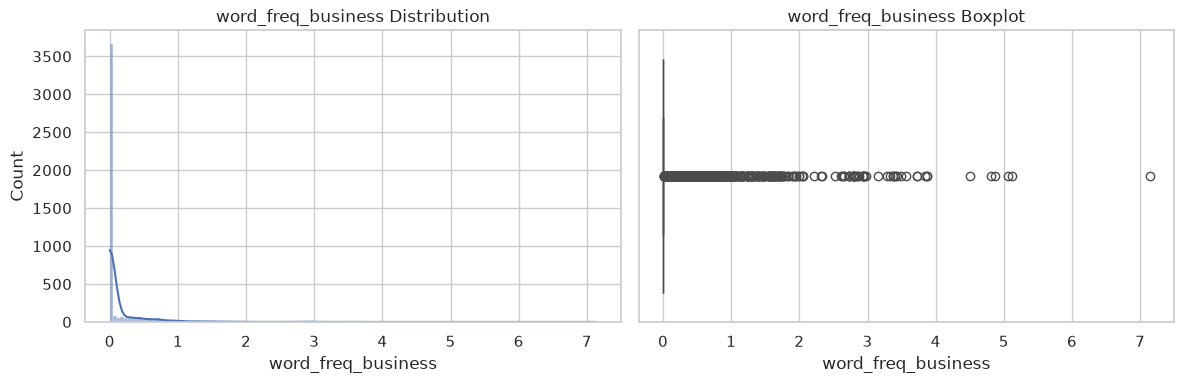

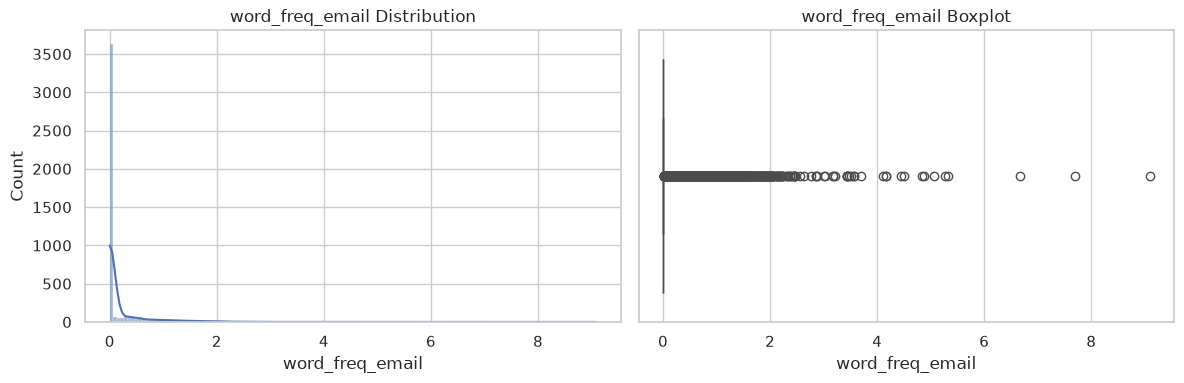

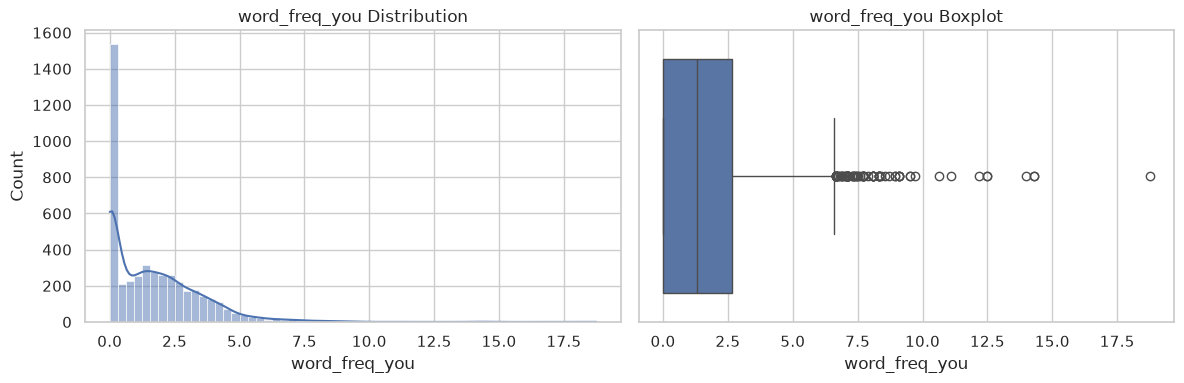

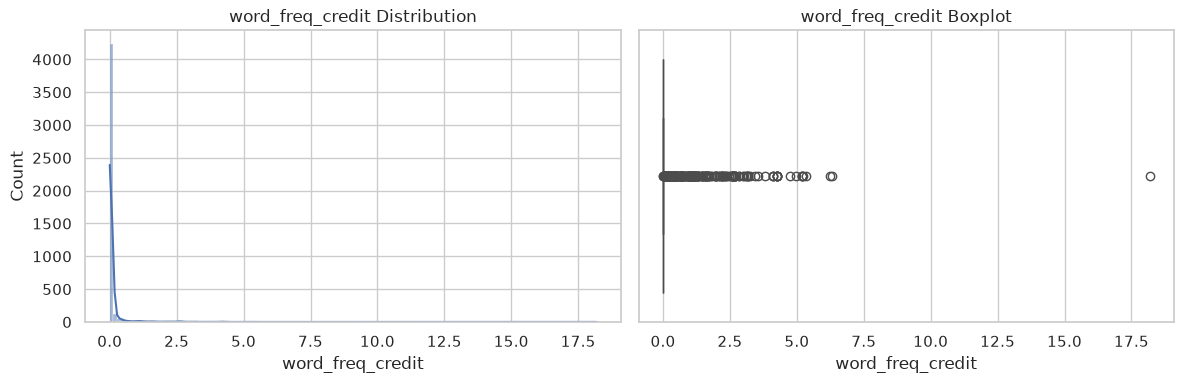

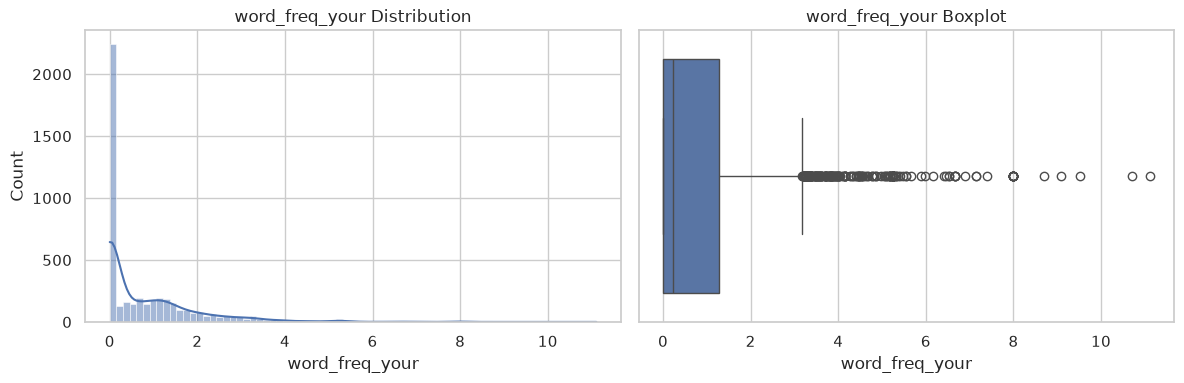

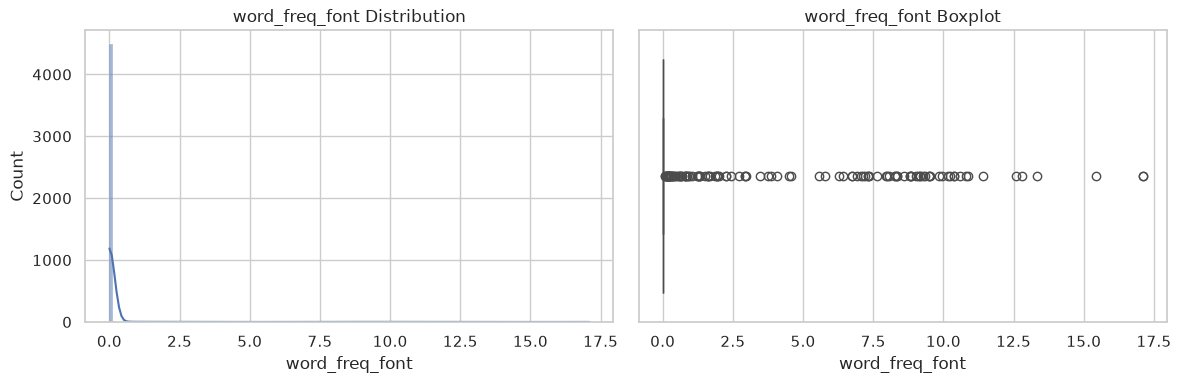

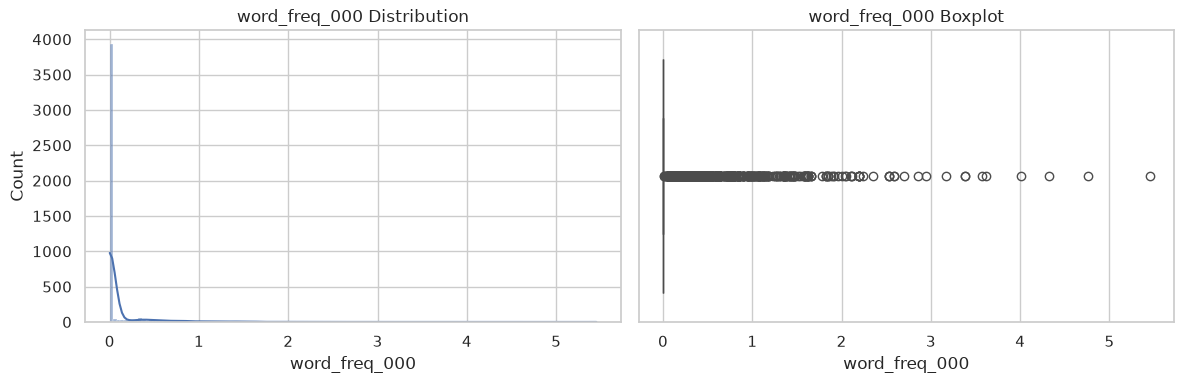

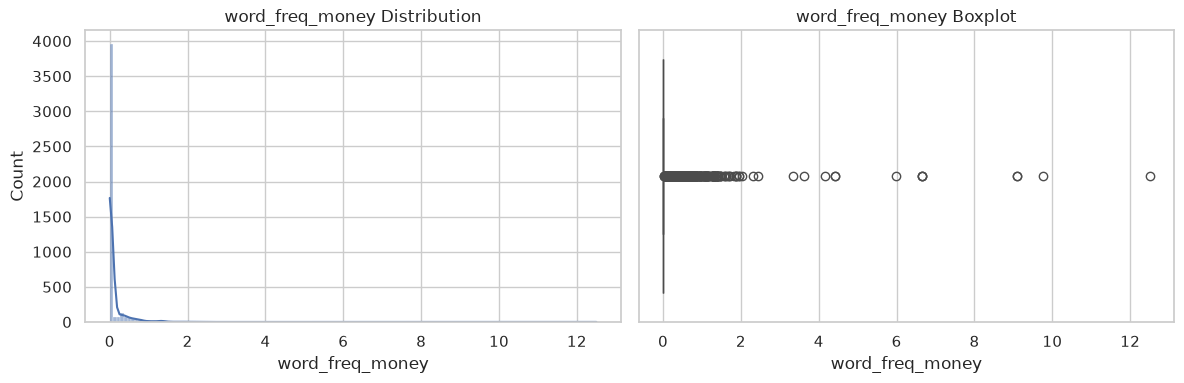

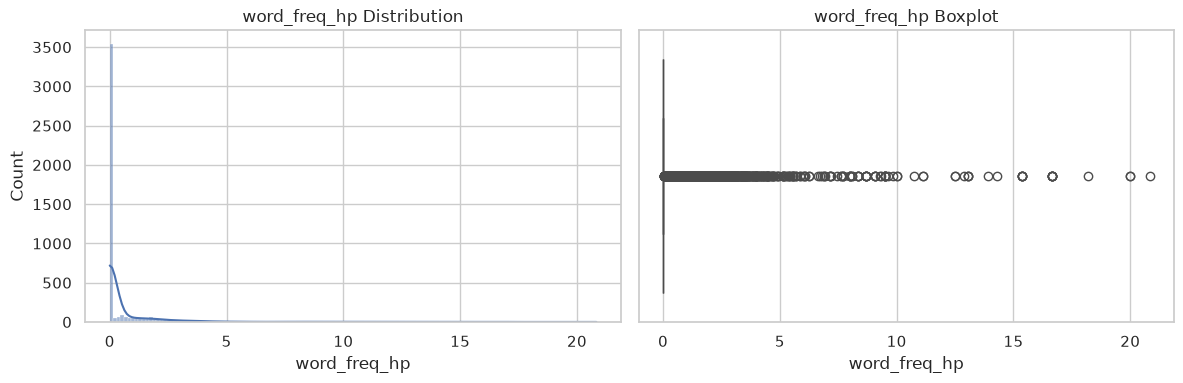

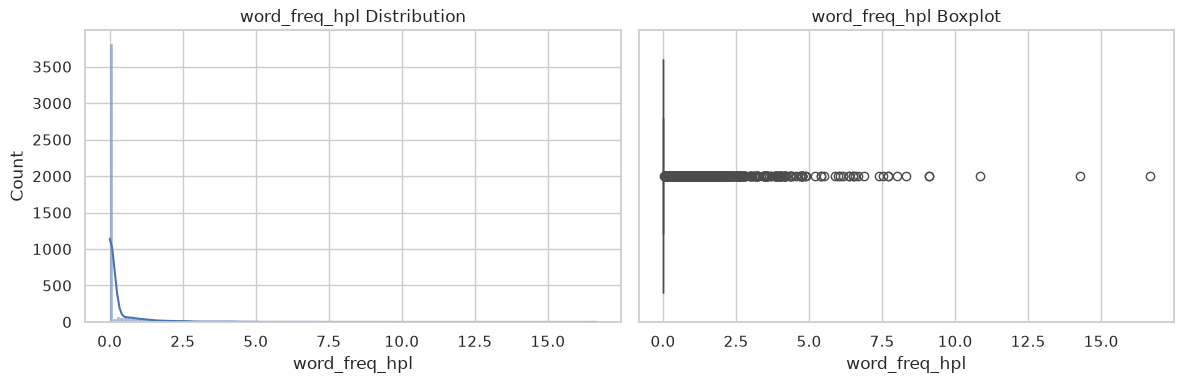

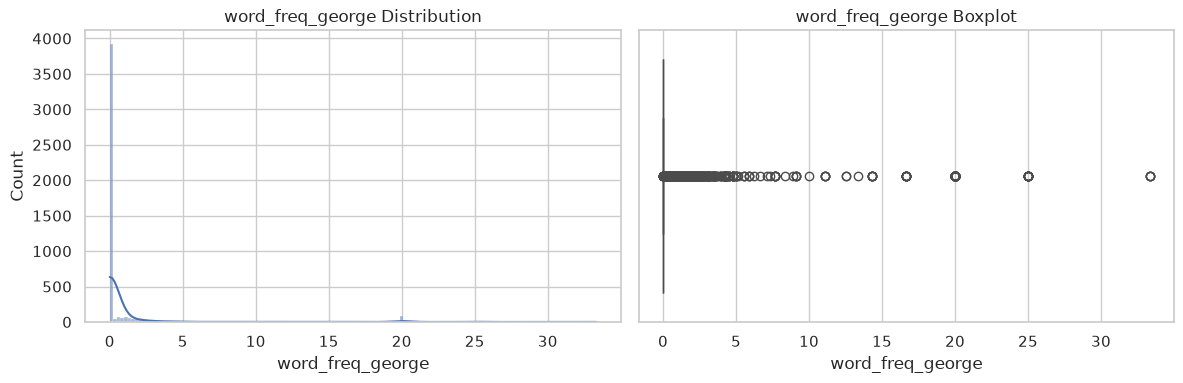

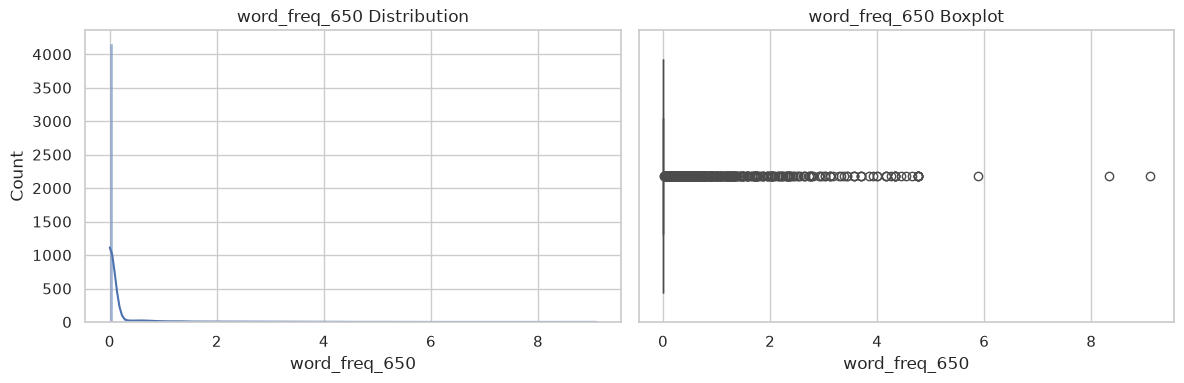

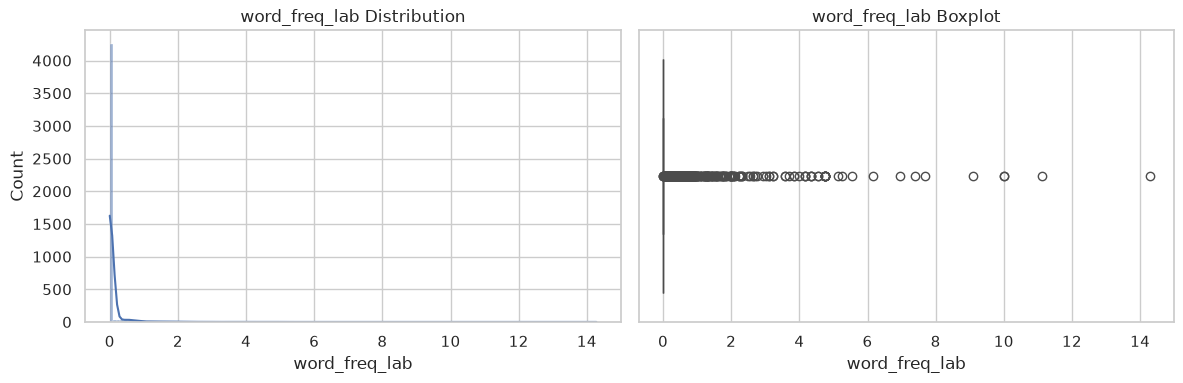

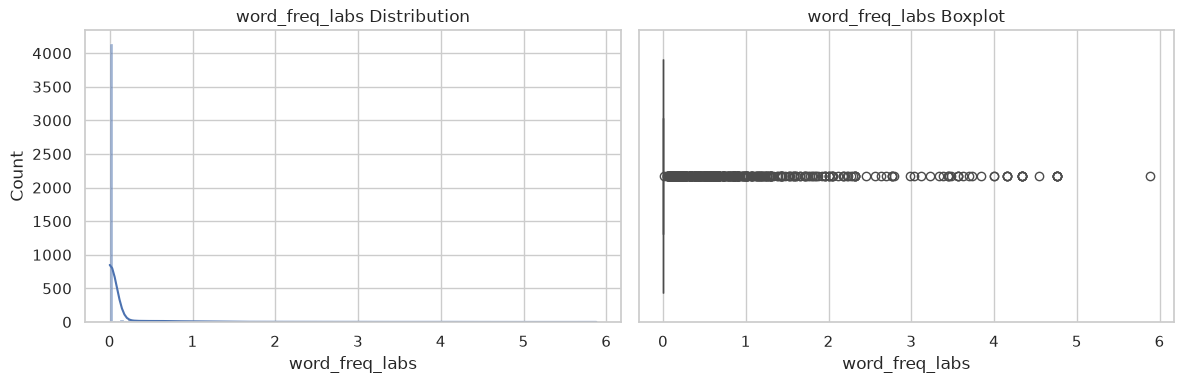

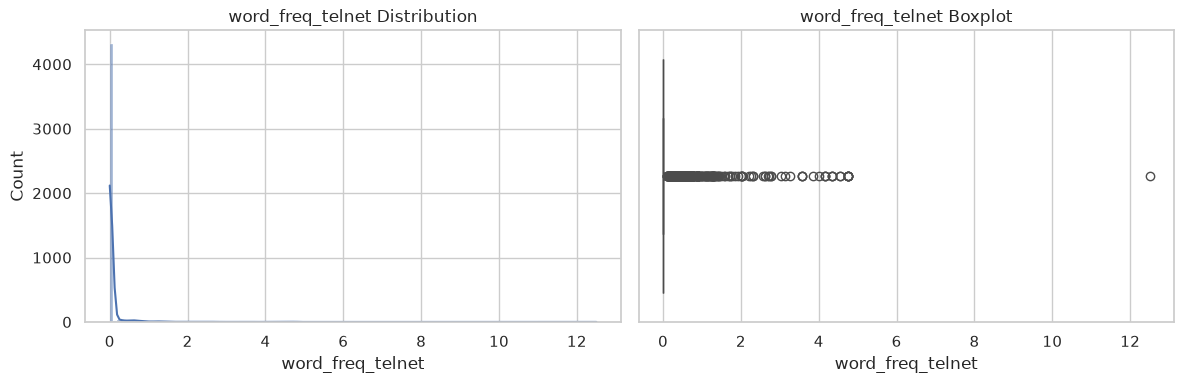

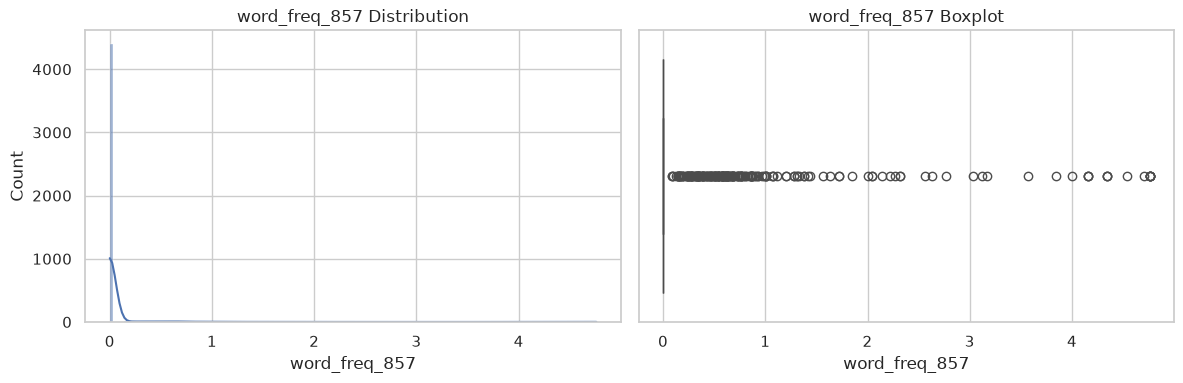

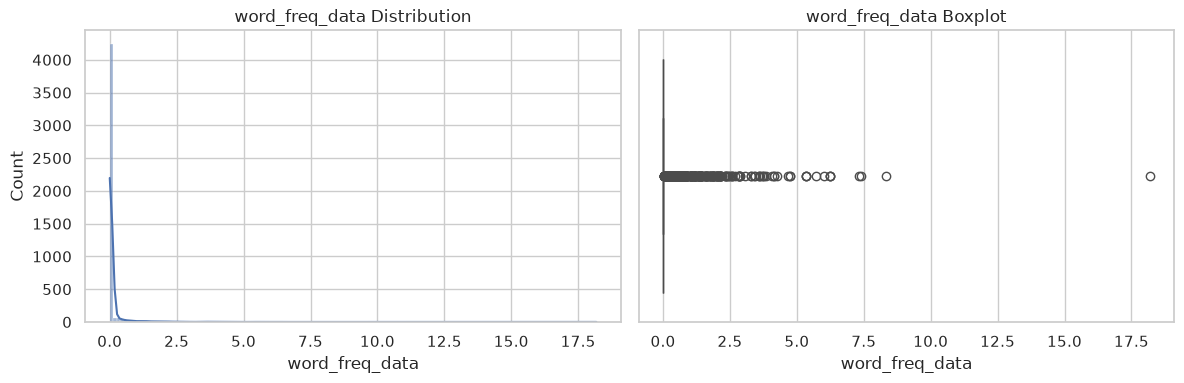

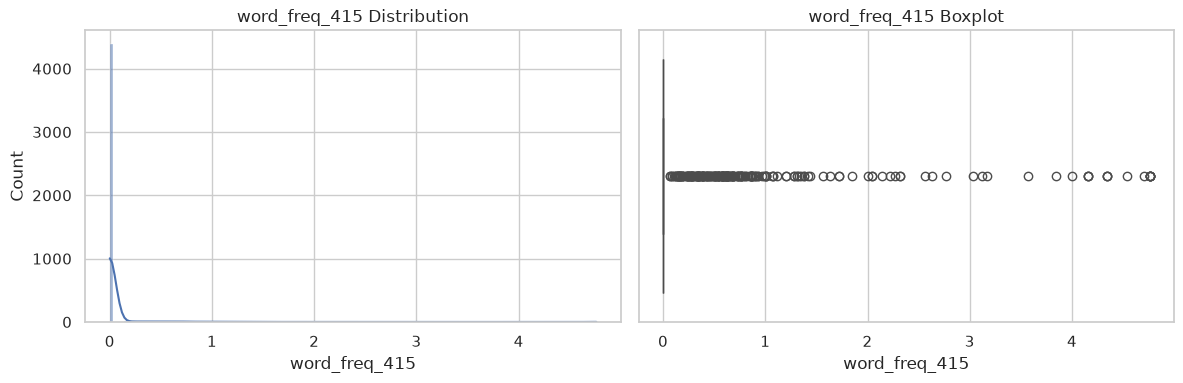

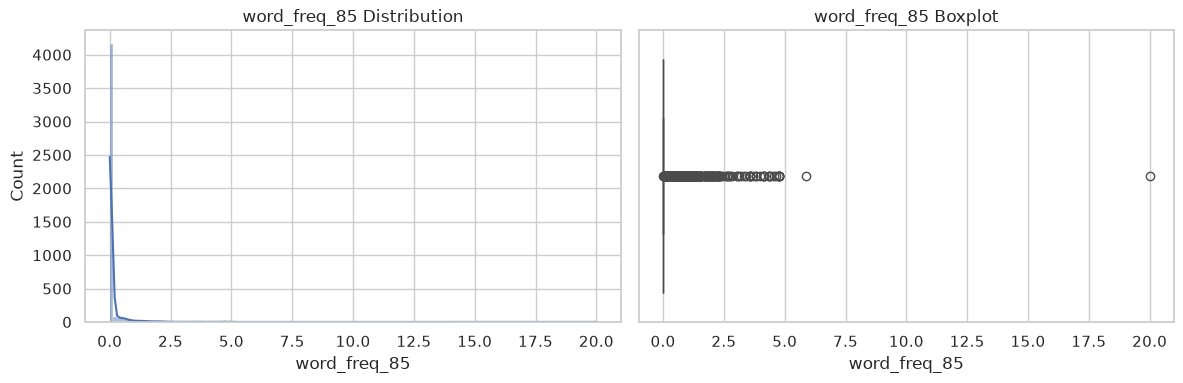

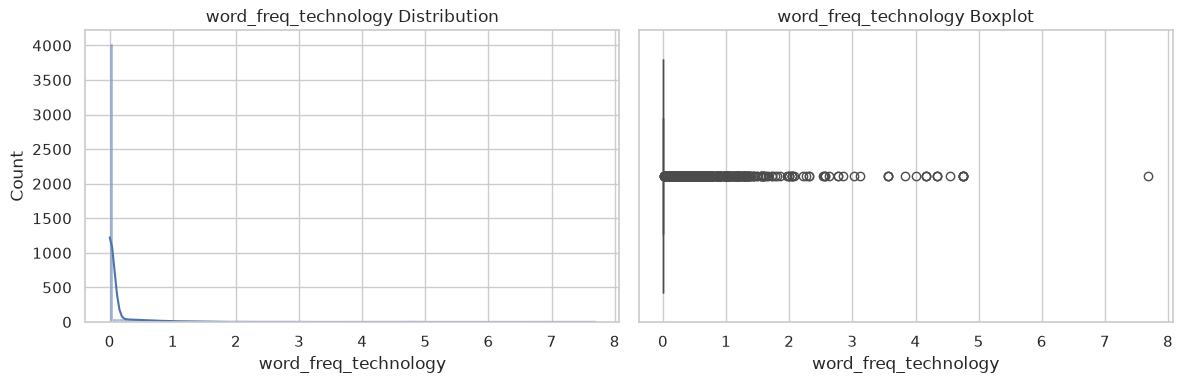

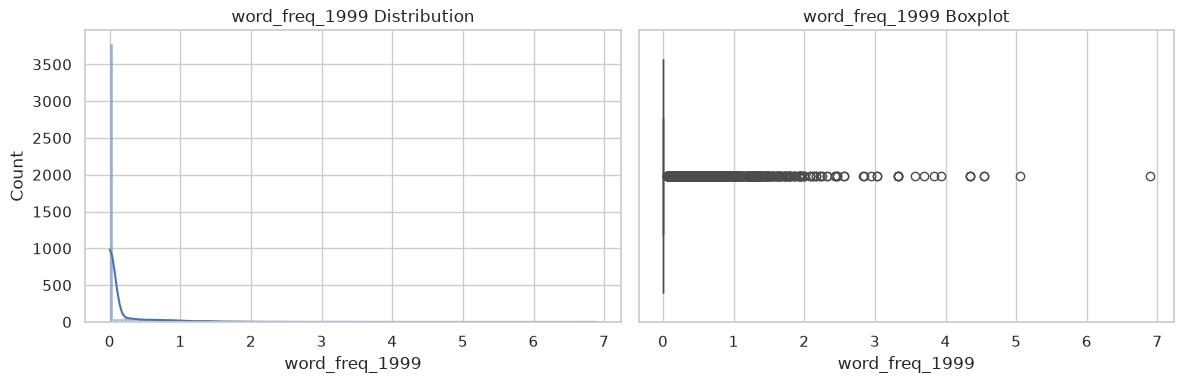

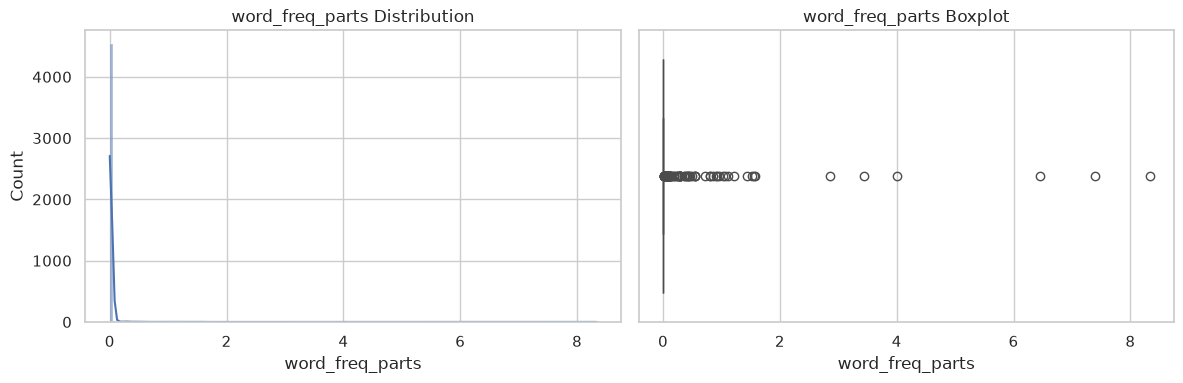

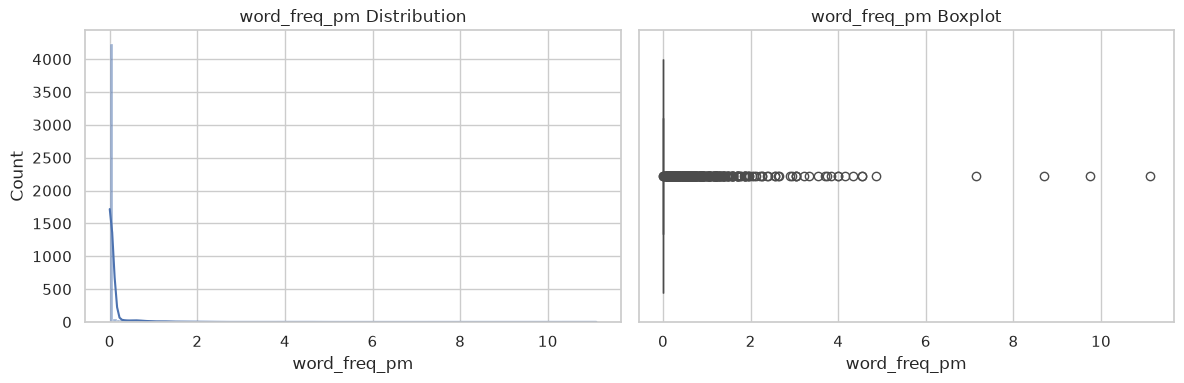

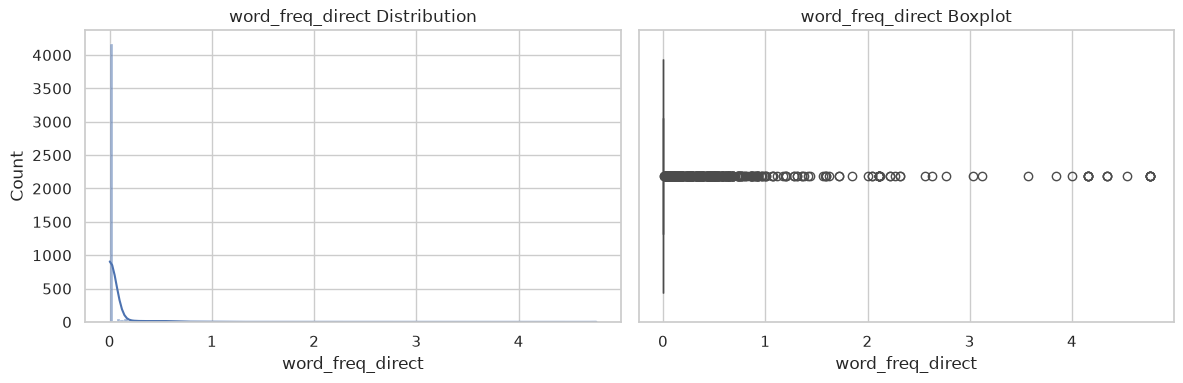

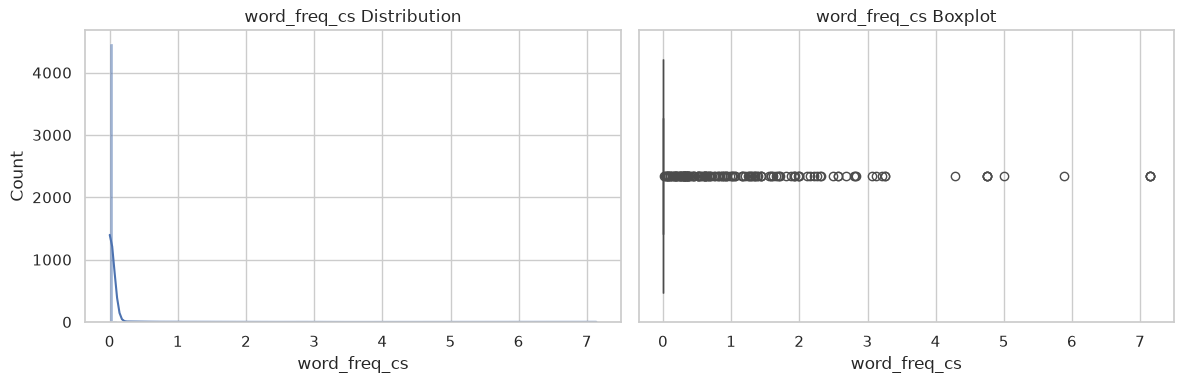

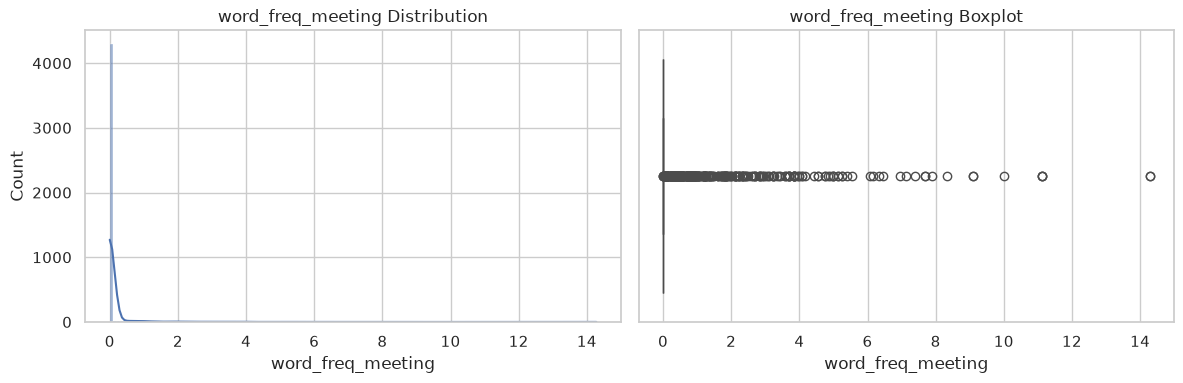

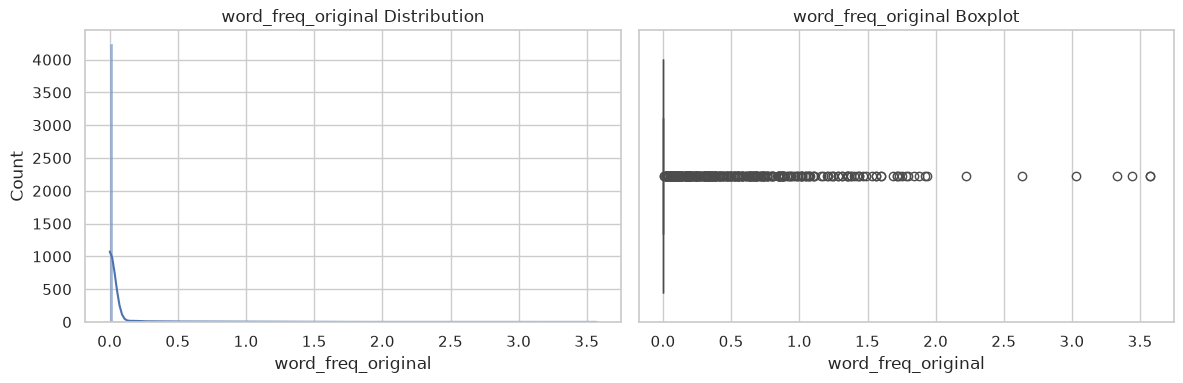

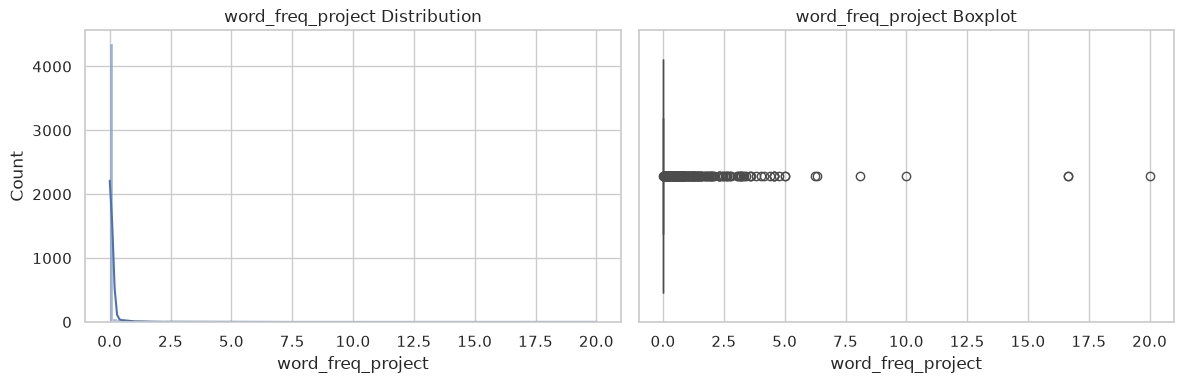

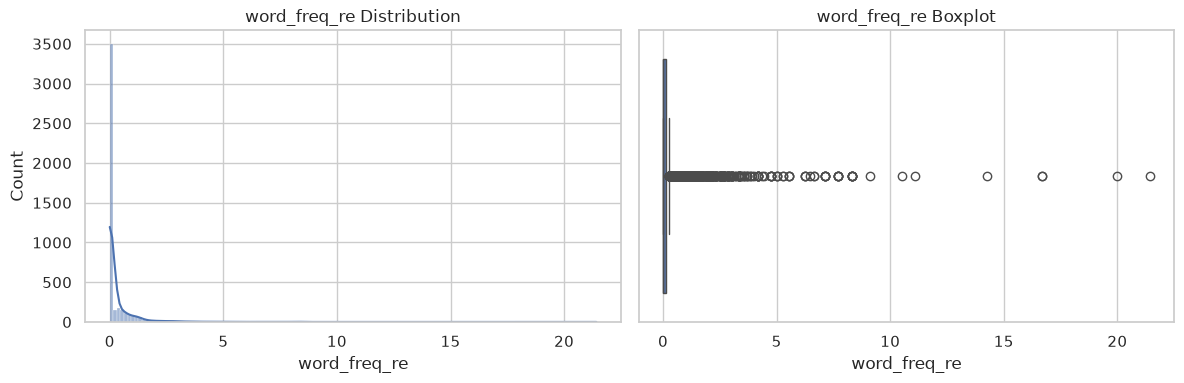

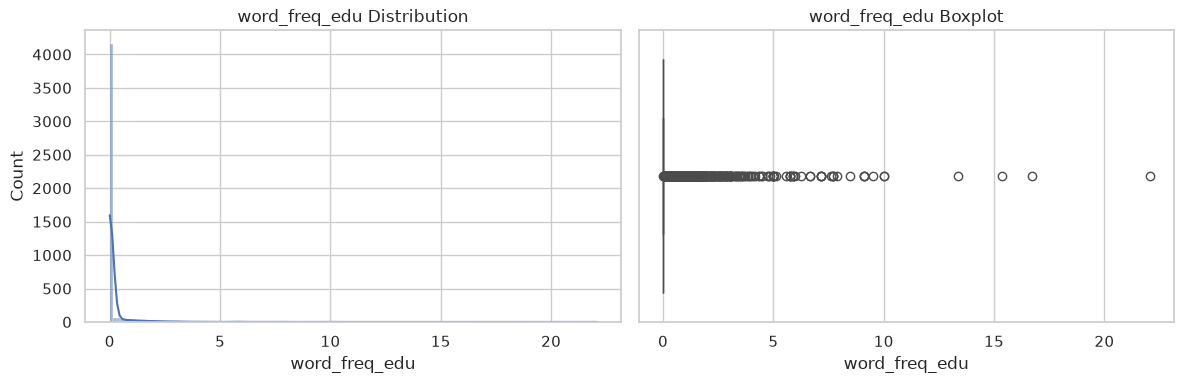

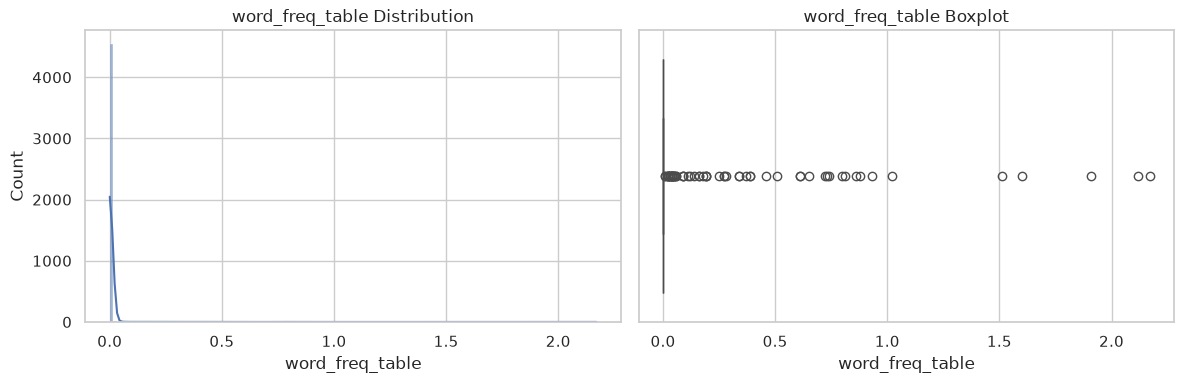

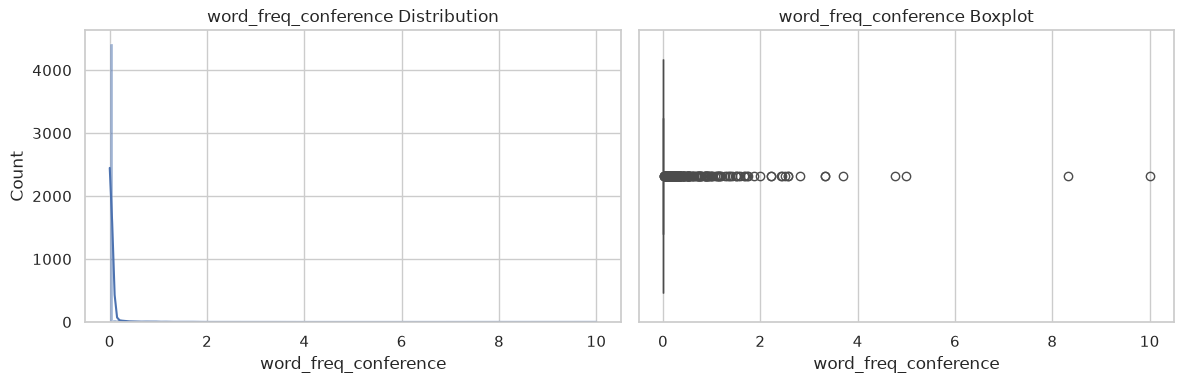

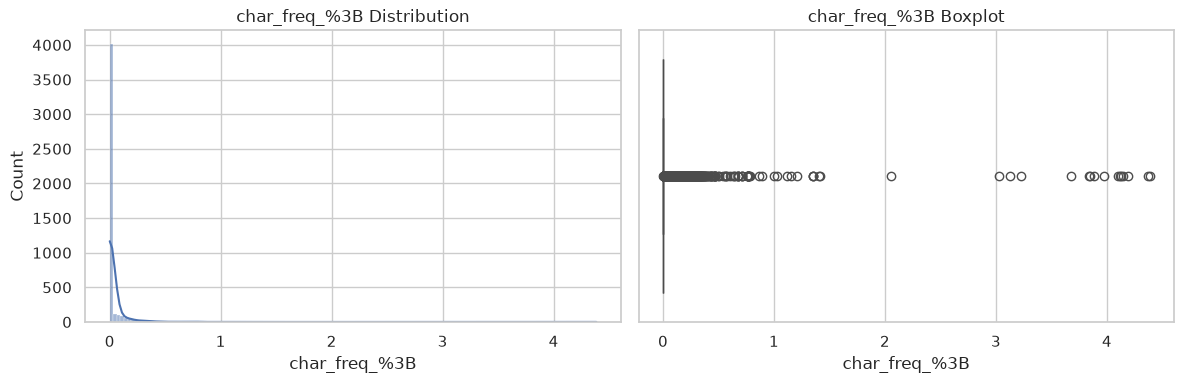

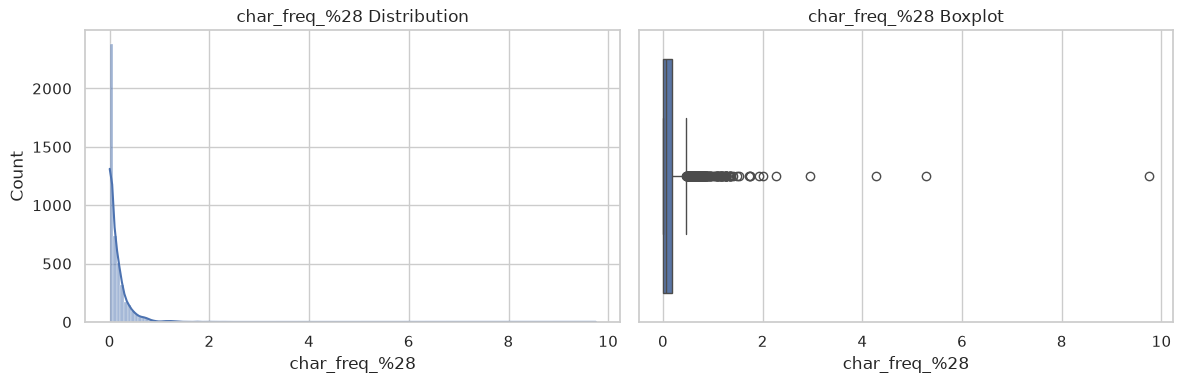

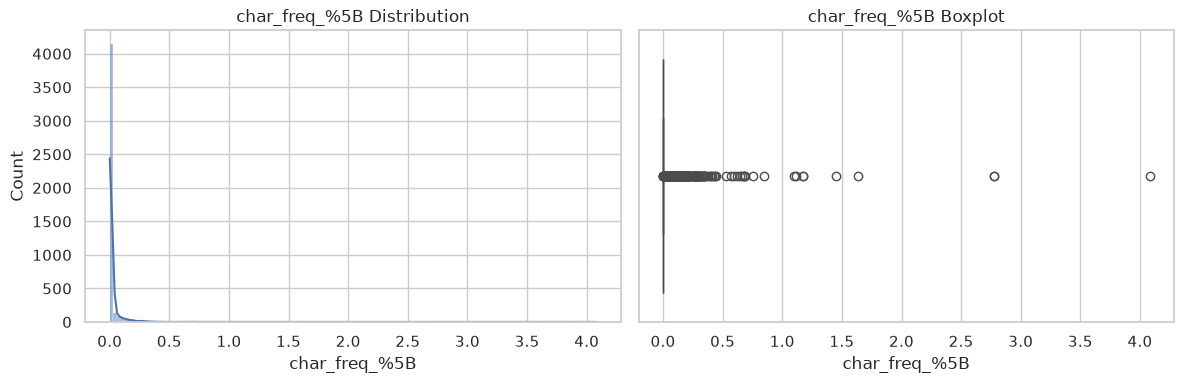

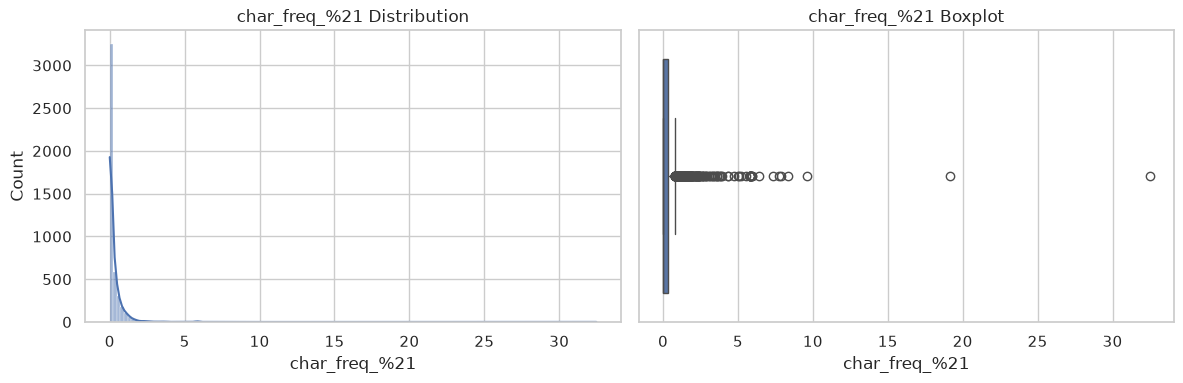

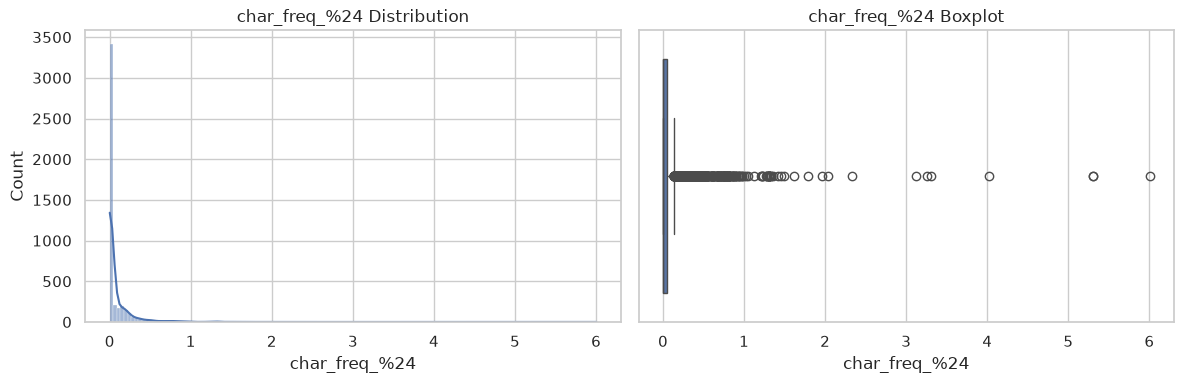

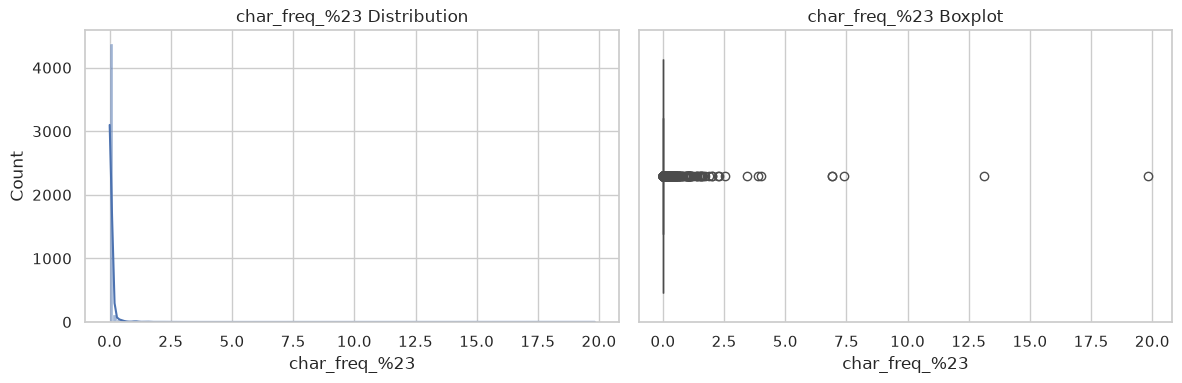

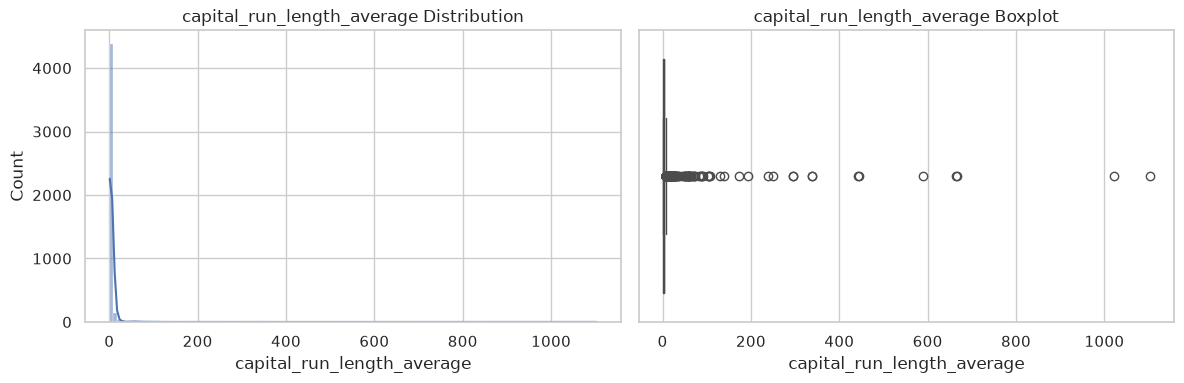

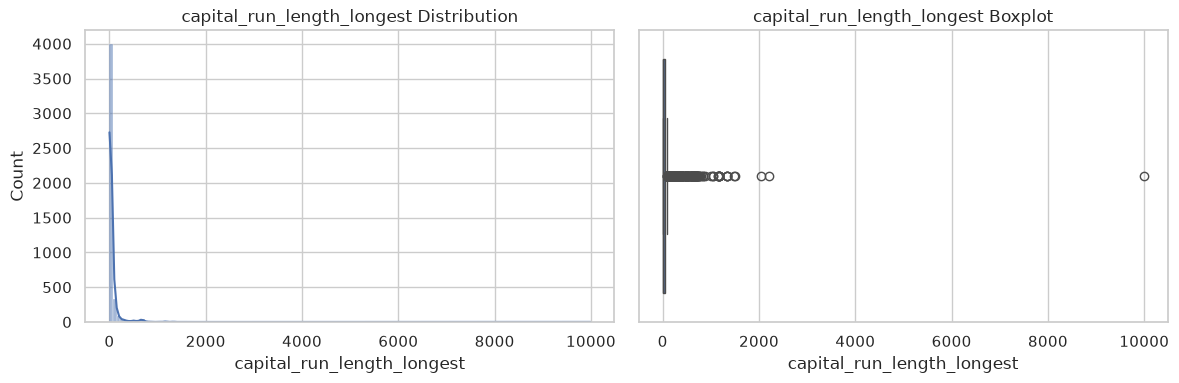

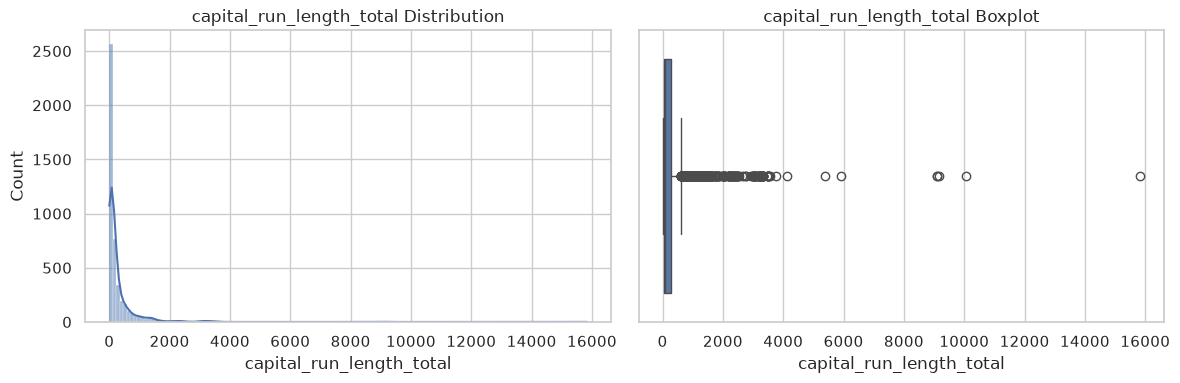

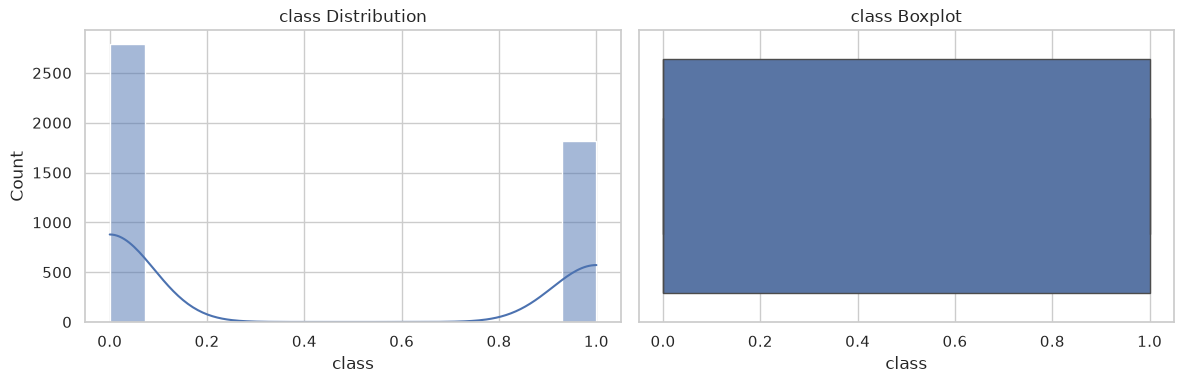

Preprocessing Completed
 Feature Engineering Completed

[PIPELINE COMPLETE]
Final Feature Shape: (4601, 14)


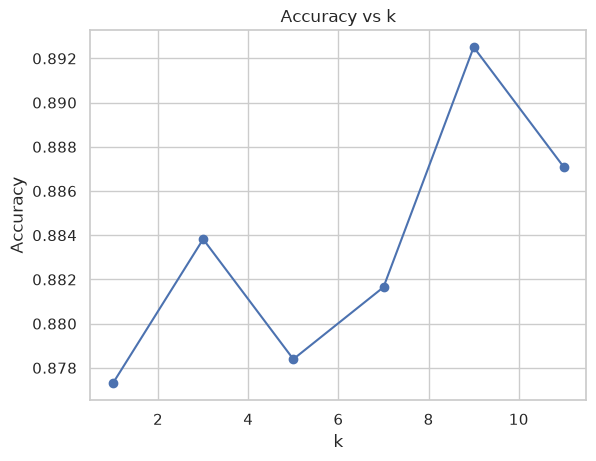


Naive Bayes Comparison
Metric    | Gaussian | Multinomial | Bernoulli
----------+----------+-------------+----------
Accuracy  | 0.8578   | 0.8556      | 0.8067   
Precision | 0.7886   | 0.8402      | 0.7403   
Recall    | 0.8733   | 0.7824      | 0.7851   
F1        | 0.8288   | 0.8103      | 0.7620   
ROC-AUC   | 0.9275   | 0.9086      | 0.8721   

KNN Comparison
k  | Accuracy | Precision | Recall | F1    
---+----------+-----------+--------+-------
1  | 0.8773   | 0.8472    | 0.8402 | 0.8437
3  | 0.8838   | 0.8596    | 0.8430 | 0.8512
5  | 0.8784   | 0.8575    | 0.8292 | 0.8431
7  | 0.8817   | 0.8692    | 0.8237 | 0.8458
9  | 0.8925   | 0.8860    | 0.8347 | 0.8596
11 | 0.8871   | 0.8776    | 0.8292 | 0.8527

Grid Search vs Randomized Search
Parameter      | GridSearchCV | RandomizedSearchCV
---------------+--------------+-------------------
Best k         | 9            | 13                
Metric         | manhattan    | manhattan         
Weights        | distance     | distance 

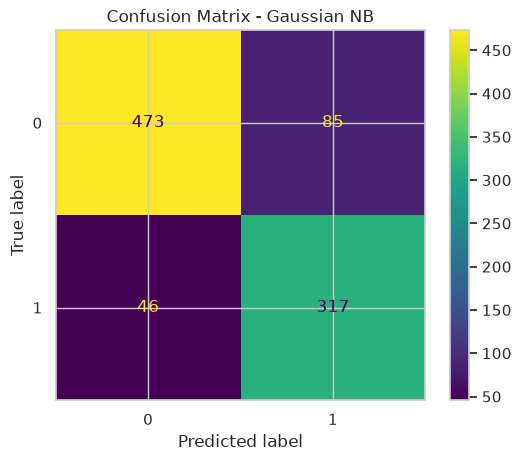

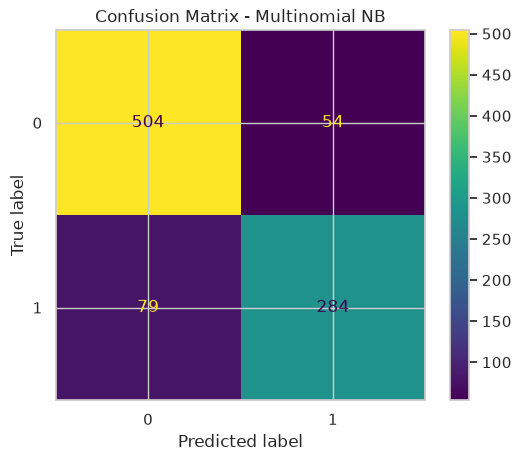

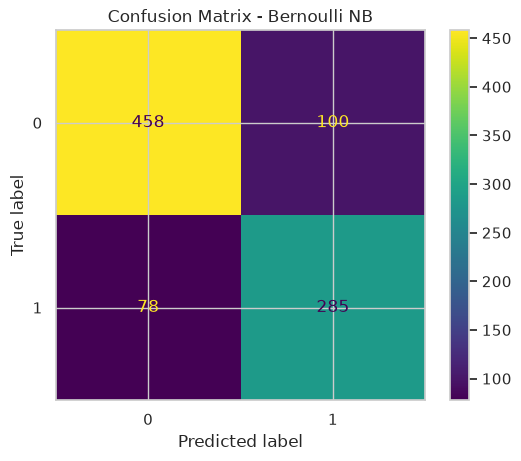

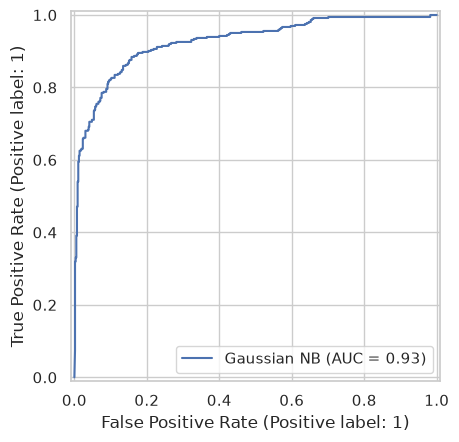

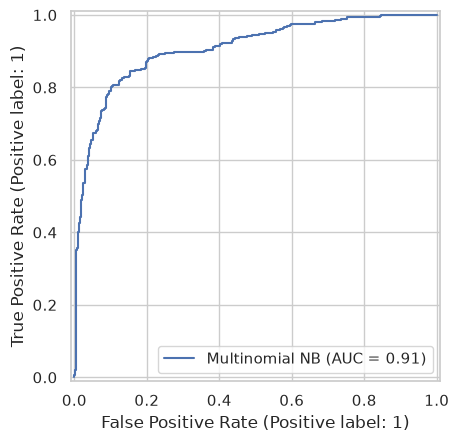

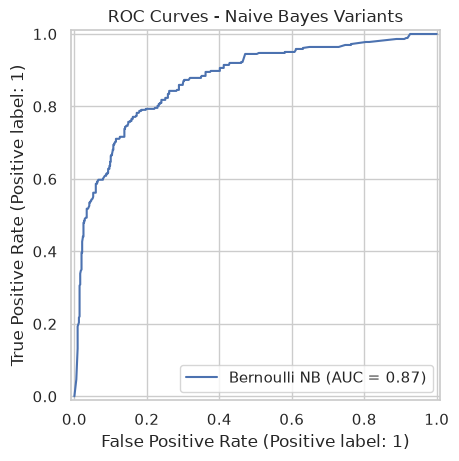

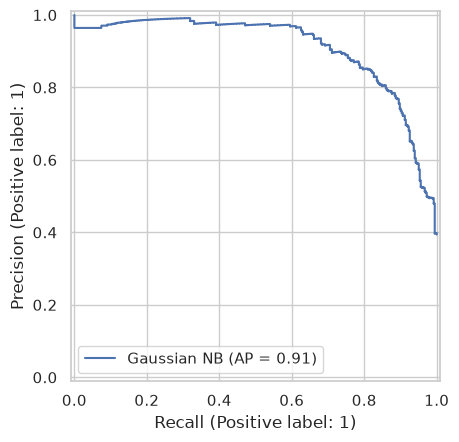

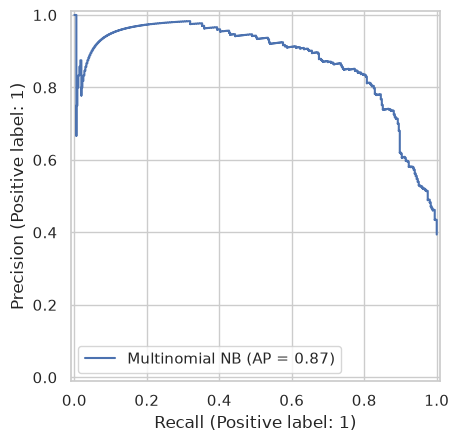

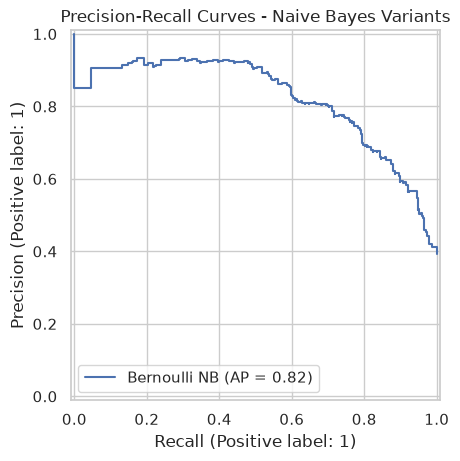


All required assignment tables are printed above in copy-friendly format.


In [1]:
import time
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tabular_pipeline as tabular_pipeline_module
importlib.reload(tabular_pipeline_module)
from tabular_pipeline import tabular_pipeline

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    precision_recall_curve,
    auc,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    roc_curve,
    average_precision_score,
    silhouette_score
    )

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier


def fmt(v, digits=4):
    if isinstance(v, (float, np.floating)):
        return f"{v:.{digits}f}"
    return str(v)


def print_table(title, headers, rows):
    str_rows = [[fmt(x) for x in row] for row in rows]
    str_headers = [str(h) for h in headers]
    widths = [len(h) for h in str_headers]

    for row in str_rows:
        for i, value in enumerate(row):
            widths[i] = max(widths[i], len(value))

    print(f"\n{title}")
    header_line = " | ".join(str_headers[i].ljust(widths[i]) for i in range(len(str_headers)))
    sep_line = "-+-".join("-" * widths[i] for i in range(len(widths)))
    print(header_line)
    print(sep_line)

    for row in str_rows:
        print(" | ".join(row[i].ljust(widths[i]) for i in range(len(row))))


pipeline_result = tabular_pipeline("spambase_csv.xls", target_col="class")
X = pipeline_result["X"]
y = pipeline_result["y"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


models = {
    "Gaussian": GaussianNB(),
    "Multinomial": MultinomialNB(),
    "Bernoulli": BernoulliNB()
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
        "train_time": train_time,
        "pred_time": pred_time,
        "y_pred": y_pred
    }


k_values = [1, 3, 5, 7, 9, 11]
knn_scores = []
knn_metric_rows = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    knn_scores.append(acc)
    knn_metric_rows.append([k, acc, prec, rec, f1])

plt.plot(k_values, knn_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.show()


param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "kd_tree", "ball_tree"],
    "metric": ["euclidean", "manhattan"]
}

grid_start = time.time()
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.time() - grid_start


param_dist = {
    "n_neighbors": np.arange(1, 20),
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "kd_tree", "ball_tree"],
    "metric": ["euclidean", "manhattan"]
}

rand_start = time.time()
rand = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
    )
rand.fit(X_train, y_train)
rand_time = time.time() - rand_start


kdtree_balltree = {}

for algo in ["kd_tree", "ball_tree"]:
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)

    start = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = knn.predict(X_test)
    pred_time = time.time() - start

    kdtree_balltree[algo] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "train_time": train_time,
        "pred_time": pred_time
    }


nb = GaussianNB()
knn_best = grid.best_estimator_

nb_cv = cross_val_score(nb, X_train, y_train, cv=5)
knn_cv = cross_val_score(knn_best, X_train, y_train, cv=5)


best_knn_start = time.time()
knn_best.fit(X_train, y_train)
best_knn_train_time = time.time() - best_knn_start

best_knn_pred_start = time.time()
best_knn_pred = knn_best.predict(X_test)
best_knn_pred_time = time.time() - best_knn_pred_start


nb_table_rows = [
    ["Accuracy", results["Gaussian"]["accuracy"], results["Multinomial"]["accuracy"], results["Bernoulli"]["accuracy"]],
    ["Precision", results["Gaussian"]["precision"], results["Multinomial"]["precision"], results["Bernoulli"]["precision"]],
    ["Recall", results["Gaussian"]["recall"], results["Multinomial"]["recall"], results["Bernoulli"]["recall"]],
    ["F1", results["Gaussian"]["f1"], results["Multinomial"]["f1"], results["Bernoulli"]["f1"]],
    ["ROC-AUC", results["Gaussian"]["roc_auc"], results["Multinomial"]["roc_auc"], results["Bernoulli"]["roc_auc"]],
]
print_table(
    "Naive Bayes Comparison",
    ["Metric", "Gaussian", "Multinomial", "Bernoulli"],
    nb_table_rows
)

print_table(
    "KNN Comparison",
    ["k", "Accuracy", "Precision", "Recall", "F1"],
    knn_metric_rows
)

grid_vs_rand_rows = [
    ["Best k", grid.best_params_["n_neighbors"], rand.best_params_["n_neighbors"]],
    ["Metric", grid.best_params_["metric"], rand.best_params_["metric"]],
    ["Weights", grid.best_params_["weights"], rand.best_params_["weights"]],
    ["Algorithm", grid.best_params_["algorithm"], rand.best_params_["algorithm"]],
    ["CV Accuracy", grid.best_score_, rand.best_score_],
    ["Execution Time", f"{grid_time:.4f} s", f"{rand_time:.4f} s"],
]
print_table(
    "Grid Search vs Randomized Search",
    ["Parameter", "GridSearchCV", "RandomizedSearchCV"],
    grid_vs_rand_rows
)

kdtree_vs_balltree_rows = [
    ["Accuracy", kdtree_balltree["kd_tree"]["accuracy"], kdtree_balltree["ball_tree"]["accuracy"]],
    ["Training Time", kdtree_balltree["kd_tree"]["train_time"], kdtree_balltree["ball_tree"]["train_time"]],
    ["Prediction Time", kdtree_balltree["kd_tree"]["pred_time"], kdtree_balltree["ball_tree"]["pred_time"]],
]
print_table(
    "KDTree vs BallTree",
    ["Metric", "KDTree", "BallTree"],
    kdtree_vs_balltree_rows
)

cv_rows = [[i + 1, nb_cv[i], knn_cv[i]] for i in range(5)]
cv_rows.append(["Average", nb_cv.mean(), knn_cv.mean()])
print_table(
    "Cross Validation",
    ["Fold", "Naive Bayes", "Best KNN"],
    cv_rows
)

theory_rows = [
    ["Naive Bayes", "O(nd)", "O(d)"],
    ["KNN (Brute)", "O(1)", "O(nd)"],
    ["KDTree", "O(nlog n)", "O(log n)avg"],
    ["BallTree", "O(nlog n)", "O(log n)avg"]
]
print_table(
    "Theoretical Time Complexity",
    ["Algorithm", "Training", "Prediction"],
    theory_rows
)

exp_time_rows = [
    ["Gaussian NB", results["Gaussian"]["train_time"], results["Gaussian"]["pred_time"]],
    ["Multinomial NB", results["Multinomial"]["train_time"], results["Multinomial"]["pred_time"]],
    ["Bernoulli NB", results["Bernoulli"]["train_time"], results["Bernoulli"]["pred_time"]],
    ["Best KNN", best_knn_train_time, best_knn_pred_time]
]
print_table(
    "Experimental Time Analysis",
    ["Algorithm", "Training(s)", "Prediction(s)"],
    exp_time_rows
)

# Optional detailed outputs for report plots and discussion
for model_name, model_obj in models.items():
    ConfusionMatrixDisplay.from_predictions(y_test, results[model_name]["y_pred"])
    plt.title(f"Confusion Matrix - {model_name} NB")
    plt.show()

for model_name, model_obj in models.items():
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=f"{model_name} NB")
plt.title("ROC Curves - Naive Bayes Variants")
plt.show()

for model_name, model_obj in models.items():
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=f"{model_name} NB")
plt.title("Precision-Recall Curves - Naive Bayes Variants")
plt.show()

print("\nAll required assignment tables are printed above in copy-friendly format.")